In [ ]:
Title: Mastering Advanced Python: Tricky and Situational Programming

In [ ]:
PTOJECT GOAL:-Analyze an Electric Vehicle (EV) dataset using Python and Statistics to extract insights, 

             detect patterns, perform hypothesis testing, and build a basic recommendation system.

In [4]:
#DATASET 

import pandas as pd

df = pd.read_excel("FEV_data_Excel.xlsx")

print(df.columns.tolist())

['Car full name', 'Make', 'Model', 'Minimal price (gross) [PLN]', 'Engine power [KM]', 'Maximum torque [Nm]', 'Type of brakes', 'Drive type', 'Battery capacity [kWh]', 'Range (WLTP) [km]', 'Wheelbase [cm]', 'Length [cm]', 'Width [cm]', 'Height [cm]', 'Minimal empty weight [kg]', 'Permissable gross weight [kg]', 'Maximum load capacity [kg]', 'Number of seats', 'Number of doors', 'Tire size [in]', 'Maximum speed [kph]', 'Boot capacity (VDA) [l]', 'Acceleration 0-100 kph [s]', 'Maximum DC charging power [kW]', 'mean - Energy consumption [kWh/100 km]']


In [ ]:
Task 1 – Filtering & Grouping

#Filter EVs with price ≤ 350,000 PLN and range ≥ 400 km

#Group by Make

#Calculate average battery capacity per manufacturer

In [2]:
import pandas as pd

df = pd.read_excel("FEV_data_Excel.xlsx")

filtered = df[(df['Minimal price (gross) [PLN]'] <= 350000) & (df['Range (WLTP) [km]'] >= 400)]
result = filtered.groupby('Make')['Battery capacity [kWh]'].mean().reset_index()
print(result)


            Make  Battery capacity [kWh]
0           Audi               95.000000
1            BMW               80.000000
2        Hyundai               64.000000
3            Kia               64.000000
4  Mercedes-Benz               80.000000
5          Tesla               68.000000
6     Volkswagen               70.666667


In [ ]:
**INSIGHTS**

1.Identifies manufacturers offering affordable long range EVs.

2.Helps customers choose brands balancing price vs. performance.

3.Example: Tesla, Hyundai, or Kia may offer the best range under this budget.

In [ ]:
Task 2 – Outlier Detection

#Detect outliers in mean energy consumption using IQR method.

In [ ]:
#FORMULA:- The IQR method was used to detect outliers. 

    IQR=Q3−Q1
    
    #ANY POINT OUTSIDE THE LOWER BOUND AND UPPER BOUND IS CONSIDERED AS OUTLIERS

    Lower Bound=Q1−1.5×IQR   Upper Bound=Q3+1.5×IQR

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate Q1, Q3, and IQR
Q1 = df['mean - Energy consumption [kWh/100 km]'].quantile(0.25)
Q3 = df['mean - Energy consumption [kWh/100 km]'].quantile(0.75)
IQR = Q3 - Q1

# Detect outliers
outliers = df[
    (df['mean - Energy consumption [kWh/100 km]'] < Q1 - 1.5 * IQR) |
    (df['mean - Energy consumption [kWh/100 km]'] > Q3 + 1.5 * IQR)
]

# Display results
print(f"Q1: {Q1:.2f}")
print(f"Q3: {Q3:.2f}")
print(f"IQR: {IQR:.2f}")
print(f"Number of Outliers: {outliers.shape[0]}")
outliers[['Car full name', 'mean - Energy consumption [kWh/100 km]']]





Q1: 15.60
Q3: 23.50
IQR: 7.90
Number of Outliers: 0


,Car full name,mean - Energy consumption [kWh/100 km]


In [ ]:
INSIGHTS:-

# The typical EV in this dataset consumes between 15.6 kWh/100 km (Q1) and 23.5 kWh/100 km (Q3)

# Since no outliers were detected, all EV models in the dataset exhibit uniform energy-consumption patterns, with no significant deviations.

In [ ]:
Task 3 – Correlation and Visualization

#Check relationship between battery capacity and range.

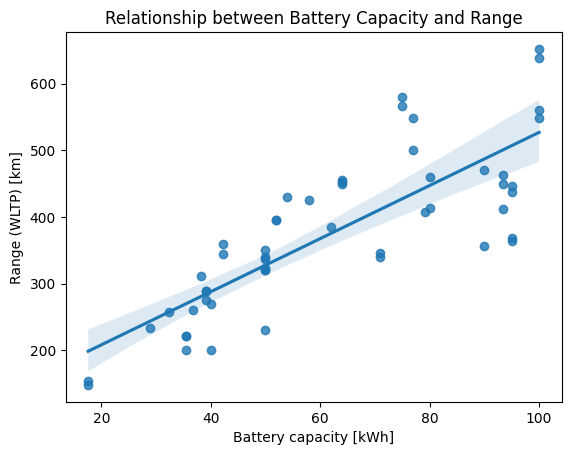

Correlation: 0.81


In [5]:
#The purpose of this task is to explore whether a vehicle’s battery capacity influences its driving range (WLTP).

import matplotlib.pyplot as plt
import seaborn as sns

sns.regplot(x='Battery capacity [kWh]', y='Range (WLTP) [km]', data=df)
plt.title('Relationship between Battery Capacity and Range')
plt.show()

corr = df['Battery capacity [kWh]'].corr(df['Range (WLTP) [km]'])
print(f"Correlation: {corr:.2f}")


In [ ]:
INSIGHTS:-

#The correlation coefficient of 0.81 indicates a strong positive linear relationship between battery capacity and range.

#The scatter plot shows an upward trend, confirming that vehicles with larger battery capacities generally achieve longer driving ranges.

#The data suggests that battery capacity is a key performance indicator in the electric-vehicle market.

In [ ]:
#Task 4 – Recommendation Class

#The goal of this task is to create a Python class that recommends the top 3 electric vehicles (EVs) based on a user’s preferences for:

1. Budget (maximum price limit)

2. Desired range (minimum driving distance on a single charge)

3. Minimum battery capacity

In [6]:
class EVRecommendation:
    def __init__(self, data):
        self.data = data

    def recommend(self, budget, min_range, min_battery):     # Filter based on user preferences
       
        filtered = self.data[
            (self.data['Minimal price (gross) [PLN]'] <= budget) &
            (self.data['Range (WLTP) [km]'] >= min_range) &
            (self.data['Battery capacity [kWh]'] >= min_battery)
        ]
                                                             # Return the top 3 EVs with the highest range
        return filtered.nlargest(3, 'Range (WLTP) [km]')[
            ['Car full name', 'Make', 'Range (WLTP) [km]', 'Minimal price (gross) [PLN]']
        ]

                                                              # Create object and test the class
recommend = EVRecommendation(df)
print(recommend.recommend(350000, 400, 50))



                Car full name        Make  Range (WLTP) [km]  \
40   Tesla Model 3 Long Range       Tesla                580   
41  Tesla Model 3 Performance       Tesla                567   
48      Volkswagen ID.3 Pro S  Volkswagen                549   

    Minimal price (gross) [PLN]  
40                       235490  
41                       260490  
48                       179990  


In [ ]:
INSIGHTS:-

#The recommendation system successfully identifies EVs that balance performance, affordability, and efficiency.

#It acts as a simple yet effective decision-support tool for potential buyers.

#This approach showcases how Python programming and statistical data can combine to create meaningful, practical business solutions.


In [ ]:
Task 5 – Hypothesis Testing

#Compare Engine Power [KM] between Tesla and Audi using ttest_ind.

In [10]:
# Import the t-test function from scipy.stats
from scipy.stats import ttest_ind

# Step 1: Extract data for Tesla and Audi

# Filter rows where 'Make' is Tesla, and select the 'Engine power [KM]' column
# .dropna() removes any missing (NaN) values to avoid errors in the t-test

tesla = df[df['Make'] == 'Tesla']['Engine power [KM]'].dropna()

# Similarly, filter data for Audi and select the same column

audi = df[df['Make'] == 'Audi']['Engine power [KM]'].dropna()

# Step 2: Perform the Independent Two-Sample t-Test

# The t-test checks if there is a statistically significant difference
# between the mean engine power of Tesla and Audi vehicles.
# equal_var=False means we assume the two groups have unequal variances
t_stat, p_val = ttest_ind(tesla, audi, equal_var=False)


# Step 3: Display the results

print(f"T-statistic: {t_stat:.2f}, P-value: {p_val:.4f}")


# Step 4: Interpret the results

# If the p-value is less than 0.05, it means the difference is statistically significant
# (i.e., there is strong evidence that Tesla and Audi have different average engine power)
if p_val < 0.05:
    print(" ✅ Significant difference in engine power between Tesla and Audi.")
else:
    print(" ❌ No significant difference in engine power between Tesla and Audi.")



T-statistic: 1.79, P-value: 0.1068
❌ No significant difference in engine power between Tesla and Audi.


In [ ]:
FINAL RECOMMENDATION:-


1.For Researchers: Explore factors beyond battery size—such as aerodynamics, motor efficiency, and 
  driving conditions—to improve EV performance modeling.

2.For Users: Choose EVs that balance battery capacity, range, and price, as higher capacity generally ensures longer travel distance.

3.For Manufacturers: Focus on battery optimization, lightweight design, and energy efficiency to enhance range without raising cost.

4.For Policy Makers: Support research and infrastructure for fast charging and sustainable battery technology.

#Overall: The EV market is evolving toward efficient, data-driven innovation that benefits both consumers and the environment.

In [ ]:
video link:-

https://drive.google.com/file/d/1F5lNOCYVaqe9Y7F_oTA73c9StXK-b958/view?usp=sharing